# # Lynceus Fraud Detection System

# ## Model Evaluation

This notebook evaluates the production-ready fraud detection model on unseen validation and test datasets.

### Objectives

- Load the trained model
- Load the preprocessing pipeline
- Apply identical preprocessing used during training
- Evaluate model performance
- Optimize the classification threshold
- Save production-ready evaluation artifacts

In [9]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    average_precision_score,

    confusion_matrix,

    classification_report,

    roc_curve,

    precision_recall_curve,

    ConfusionMatrixDisplay,

    RocCurveDisplay,

    PrecisionRecallDisplay

)

In [12]:
DATA_DIR = Path("/Users/lakshaydahiya/Desktop/engineerOS/01_projects/lynceus/backend/app/ml/data/synthetic")

ARTIFACT_DIR = Path("/Users/lakshaydahiya/Desktop/engineerOS/01_projects/lynceus/backend/app/ml/artifacts")

VAL_PATH = DATA_DIR / "transactions_val.csv"

TEST_PATH = DATA_DIR / "transactions_test.csv"

PIPELINE_PATH = ARTIFACT_DIR / "preprocessing_pipeline.joblib"

MODEL_PATH = ARTIFACT_DIR / "best_model.joblib"

In [13]:
val_df = pd.read_csv(
    VAL_PATH,
    parse_dates=["timestamp"]
)

test_df = pd.read_csv(
    TEST_PATH,
    parse_dates=["timestamp"]
)

print("Validation :", val_df.shape)
print("Test :", test_df.shape)

Validation : (15000, 23)
Test : (15000, 23)


In [15]:
TARGET = "fraud_label"

X_val = val_df.drop(columns=TARGET)
y_val = val_df[TARGET]

X_test = test_df.drop(columns=TARGET)
y_test = test_df[TARGET]

In [16]:
binary_features = [

    "is_weekend",

    "is_new_receiver",

    "device_trusted",

    "cross_border",

    "high_risk_country"

]

for df in [X_val, X_test]:

    df.drop(
        columns="timestamp",
        inplace=True
    )

    df[binary_features] = df[binary_features].astype("int8")

In [17]:
preprocessor = joblib.load(
    PIPELINE_PATH
)

best_model = joblib.load(
    MODEL_PATH
)

print(type(preprocessor))
print(type(best_model))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'lightgbm.sklearn.LGBMClassifier'>


In [18]:
X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_val_processed = pd.DataFrame(

    X_val_processed,

    columns=feature_names

)

X_test_processed = pd.DataFrame(

    X_test_processed,

    columns=feature_names
)

print(X_val_processed.shape)
print(X_test_processed.shape)

(15000, 41)
(15000, 41)


# # Generate Predictions

The trained model predicts:

- Fraud probability
- Predicted class (default threshold = 0.50)

In [19]:
y_val_prob = best_model.predict_proba(X_val_processed)[:, 1]
y_test_prob = best_model.predict_proba(X_test_processed)[:, 1]

y_val_pred = best_model.predict(X_val_processed)
y_test_pred = best_model.predict(X_test_processed)

# # Validation Metrics

In [20]:
validation_metrics = {

    "Accuracy": accuracy_score(y_val, y_val_pred),

    "Precision": precision_score(y_val, y_val_pred),

    "Recall": recall_score(y_val, y_val_pred),

    "F1 Score": f1_score(y_val, y_val_pred),

    "ROC-AUC": roc_auc_score(y_val, y_val_prob),

    "PR-AUC": average_precision_score(y_val, y_val_prob)

}

pd.DataFrame(
    validation_metrics,
    index=["Validation"]
)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Validation,0.984467,0.734234,0.48368,0.583184,0.883758,0.583684


# # Test Metrics

In [21]:
test_metrics = {

    "Accuracy": accuracy_score(y_test, y_test_pred),

    "Precision": precision_score(y_test, y_test_pred),

    "Recall": recall_score(y_test, y_test_pred),

    "F1 Score": f1_score(y_test, y_test_pred),

    "ROC-AUC": roc_auc_score(y_test, y_test_prob),

    "PR-AUC": average_precision_score(y_test, y_test_prob)

}

pd.DataFrame(
    test_metrics,
    index=["Test"]
)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Test,0.9834,0.741463,0.436782,0.549729,0.866302,0.564067


# # Combined Evaluation Summary

In [22]:
evaluation_df = pd.DataFrame(

    [

        validation_metrics,

        test_metrics

    ],

    index=[

        "Validation",

        "Test"

    ]

)

evaluation_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Validation,0.984467,0.734234,0.483680,0.583184,0.883758,0.583684
Test,0.983400,0.741463,0.436782,0.549729,0.866302,0.564067


# # Classification Report

In [23]:
print("=" * 70)
print("Validation Classification Report")
print("=" * 70)

print(

    classification_report(

        y_val,

        y_val_pred

    )

)

Validation Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     14663
           1       0.73      0.48      0.58       337

    accuracy                           0.98     15000
   macro avg       0.86      0.74      0.79     15000
weighted avg       0.98      0.98      0.98     15000



In [24]:
print("=" * 70)
print("Test Classification Report")
print("=" * 70)

print(

    classification_report(

        y_test,

        y_test_pred

    )

)

Test Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     14652
           1       0.74      0.44      0.55       348

    accuracy                           0.98     15000
   macro avg       0.86      0.72      0.77     15000
weighted avg       0.98      0.98      0.98     15000



# # Confusion Matrix

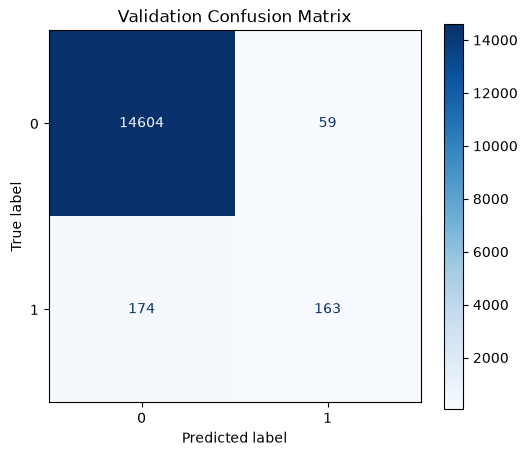

In [25]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(

    y_val,

    y_val_pred,

    cmap="Blues",

    ax=ax

)

plt.title("Validation Confusion Matrix")

plt.show()

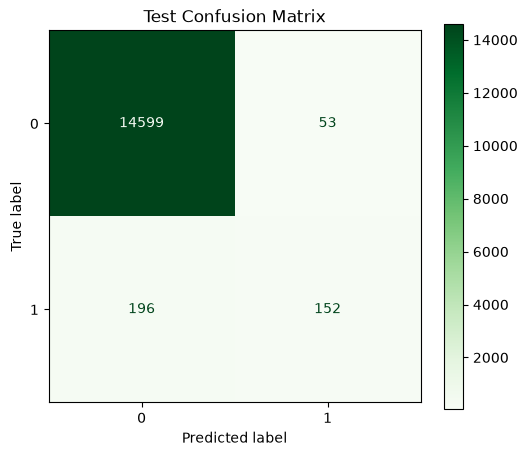

In [26]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_test_pred,

    cmap="Greens",

    ax=ax

)

plt.title("Test Confusion Matrix")

plt.show()

# # ROC Curve

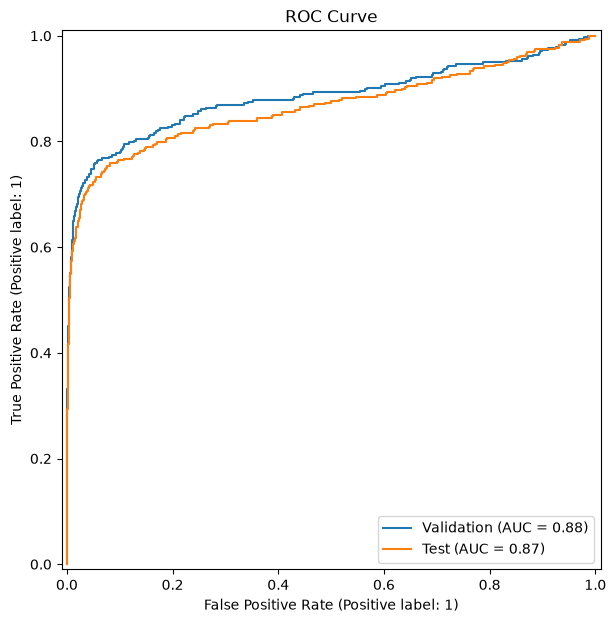

In [27]:
fig, ax = plt.subplots(figsize=(7,7))

RocCurveDisplay.from_predictions(

    y_val,

    y_val_prob,

    ax=ax,

    name="Validation"

)

RocCurveDisplay.from_predictions(

    y_test,

    y_test_prob,

    ax=ax,

    name="Test"

)

plt.title("ROC Curve")

plt.show()

# # Precision-Recall Curve

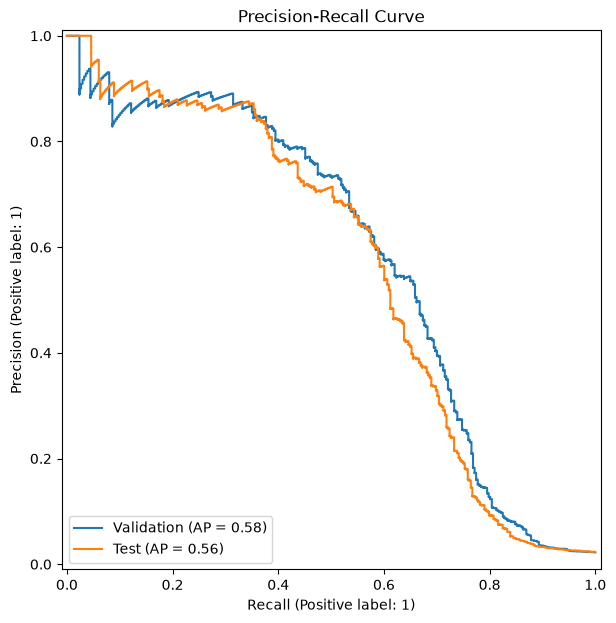

In [28]:
fig, ax = plt.subplots(figsize=(7,7))

PrecisionRecallDisplay.from_predictions(

    y_val,

    y_val_prob,

    ax=ax,

    name="Validation"

)

PrecisionRecallDisplay.from_predictions(

    y_test,

    y_test_prob,

    ax=ax,

    name="Test"

)

plt.title("Precision-Recall Curve")

plt.show()

# # Threshold Optimization

Instead of using the default classification threshold of **0.50**, we evaluate multiple thresholds on the validation set.

The threshold that maximizes the **F1 Score** is selected for production deployment.

In [29]:
thresholds = np.arange(0.05, 1.00, 0.01)

threshold_results = []

for threshold in thresholds:

    y_pred = (y_val_prob >= threshold).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Precision": precision_score(
            y_val,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_val,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_val,
            y_pred,
            zero_division=0
        )

    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.05,0.274211,0.747774,0.401274
1,0.06,0.309735,0.727003,0.434397
2,0.07,0.339385,0.721068,0.461538
3,0.08,0.365152,0.715134,0.483450
4,0.09,0.386364,0.706231,0.499475


In [30]:
# best threshold

best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

optimal_threshold = float(best_row["Threshold"])

print(f"Optimal Threshold : {optimal_threshold:.2f}")

best_row

Optimal Threshold : 0.40


Threshold    0.400000
Precision    0.705882
Recall       0.534125
F1           0.608108
Name: 35, dtype: float64

# # Threshold Performance

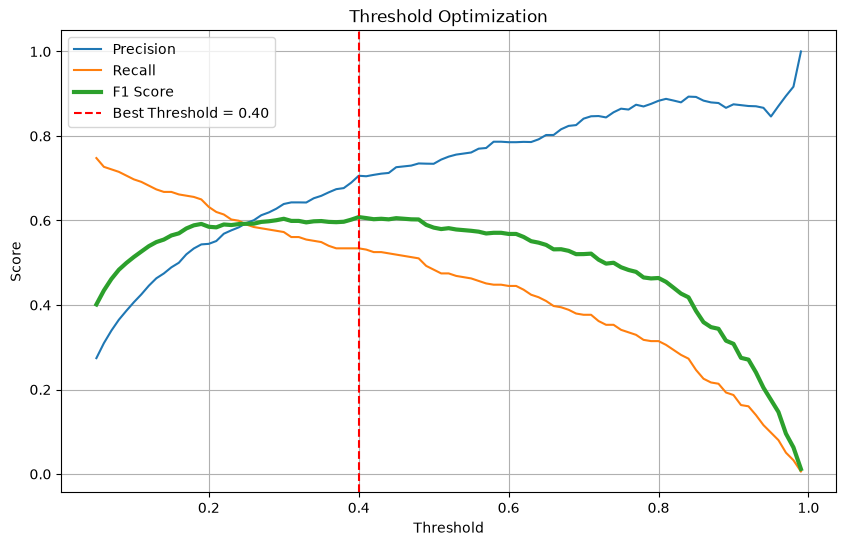

In [31]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1 Score",
    linewidth=3
)

plt.axvline(
    optimal_threshold,
    color="red",
    linestyle="--",
    label=f"Best Threshold = {optimal_threshold:.2f}"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.legend()

plt.grid(True)

plt.show()

# # Re-evaluate Using Optimal Threshold

In [32]:
y_val_pred_opt = (
    y_val_prob >= optimal_threshold
).astype(int)

optimized_metrics = {

    "Accuracy": accuracy_score(
        y_val,
        y_val_pred_opt
    ),

    "Precision": precision_score(
        y_val,
        y_val_pred_opt,
        zero_division=0
    ),

    "Recall": recall_score(
        y_val,
        y_val_pred_opt,
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_val,
        y_val_pred_opt,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_val,
        y_val_prob
    ),

    "PR-AUC": average_precision_score(
        y_val,
        y_val_prob
    )

}

pd.DataFrame(
    optimized_metrics,
    index=["Optimized Threshold"]
)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Optimized Threshold,0.984533,0.705882,0.534125,0.608108,0.883758,0.583684


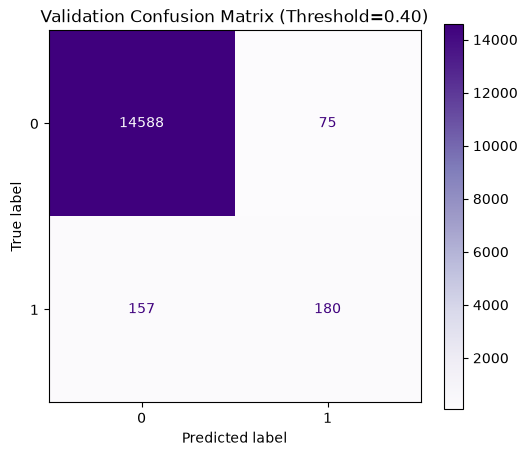

In [33]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(

    y_val,

    y_val_pred_opt,

    cmap="Purples",

    ax=ax

)

plt.title(
    f"Validation Confusion Matrix (Threshold={optimal_threshold:.2f})"
)

plt.show()

In [34]:
print("=" * 70)

print(
    f"Classification Report (Threshold = {optimal_threshold:.2f})"
)

print("=" * 70)

print(

    classification_report(

        y_val,

        y_val_pred_opt,

        zero_division=0

    )

)

Classification Report (Threshold = 0.40)
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     14663
           1       0.71      0.53      0.61       337

    accuracy                           0.98     15000
   macro avg       0.85      0.76      0.80     15000
weighted avg       0.98      0.98      0.98     15000



# # Compare Default vs Optimized Threshold

In [35]:
comparison_df = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Default (0.50)": [

        validation_metrics["Accuracy"],

        validation_metrics["Precision"],

        validation_metrics["Recall"],

        validation_metrics["F1 Score"]

    ],

    "Optimized": [

        optimized_metrics["Accuracy"],

        optimized_metrics["Precision"],

        optimized_metrics["Recall"],

        optimized_metrics["F1 Score"]

    ]

})

comparison_df

,Metric,Default (0.50),Optimized
0,Accuracy,0.984467,0.984533
1,Precision,0.734234,0.705882
2,Recall,0.483680,0.534125
3,F1 Score,0.583184,0.608108


# # Save Model Metadata

# Save all production metadata required by the backend.

In [42]:
model_metadata = {

    "model_name": type(best_model).__name__,

    "model_version": "1.0.0",

    "optimal_threshold": float(optimal_threshold),

    "feature_count": int(X_val_processed.shape[1]),

    "validation_metrics": {

        "accuracy": float(optimized_metrics["Accuracy"]),

        "precision": float(optimized_metrics["Precision"]),

        "recall": float(optimized_metrics["Recall"]),

        "f1_score": float(optimized_metrics["F1 Score"]),

        "roc_auc": float(optimized_metrics["ROC-AUC"]),

        "pr_auc": float(optimized_metrics["PR-AUC"])

    },

    "test_metrics": {

        "accuracy": float(test_metrics["Accuracy"]),

        "precision": float(test_metrics["Precision"]),

        "recall": float(test_metrics["Recall"]),

        "f1_score": float(test_metrics["F1 Score"]),

        "roc_auc": float(test_metrics["ROC-AUC"]),

        "pr_auc": float(test_metrics["PR-AUC"])

    }

}

metadata_path = ARTIFACT_DIR / "model_metadata.json"

with open(metadata_path, "w") as f:

    json.dump(
        model_metadata,
        f,
        indent=4
    )

print(f"Metadata saved to:\n{metadata_path}")

Metadata saved to:
/Users/lakshaydahiya/Desktop/engineerOS/01_projects/lynceus/backend/app/ml/artifacts/model_metadata.json


# # Save Threshold Search Results

All evaluated thresholds are stored for future analysis.

In [43]:
threshold_csv_path = ARTIFACT_DIR / "threshold_results.csv"

threshold_df.to_csv(
    threshold_csv_path,
    index=False
)

print(f"Threshold search results saved to:\n{threshold_csv_path}")

Threshold search results saved to:
/Users/lakshaydahiya/Desktop/engineerOS/01_projects/lynceus/backend/app/ml/artifacts/threshold_results.csv


# # Verify Generated Artifacts

In [44]:
print("=" * 60)
print("Artifacts")
print("=" * 60)

expected_files = [

    "best_model.joblib",

    "preprocessing_pipeline.joblib",

    "model_metadata.json",

    "threshold_results.csv"

]

for file in expected_files:

    print(f"• {file}")

Artifacts
• best_model.joblib
• preprocessing_pipeline.joblib
• model_metadata.json
• threshold_results.csv


In [ ]:
# # Evaluation Summary

In [45]:
print("=" * 70)
print("Lynceus Fraud Detection Evaluation Completed")
print("=" * 70)

print(f"Model                : {type(best_model).__name__}")
print(f"Optimal Threshold    : {optimal_threshold:.2f}")

print("\nValidation Metrics")
for key, value in optimized_metrics.items():
    print(f"{key:<12}: {value:.4f}")

print("\nTest Metrics")
for key, value in test_metrics.items():
    print(f"{key:<12}: {value:.4f}")

print("\nArtifacts Generated")

print(f"• {MODEL_PATH.name}")
print(f"• {PIPELINE_PATH.name}")
print(f"• {MODEL_PATH.name}")
print(f"• {PIPELINE_PATH.name}")
print(f"• {metadata_path.name}")
print(f"• {threshold_csv_path.name}")

print("=" * 70)

Lynceus Fraud Detection Evaluation Completed
Model                : LGBMClassifier
Optimal Threshold    : 0.40

Validation Metrics
Accuracy    : 0.9845
Precision   : 0.7059
Recall      : 0.5341
F1 Score    : 0.6081
ROC-AUC     : 0.8838
PR-AUC      : 0.5837

Test Metrics
Accuracy    : 0.9834
Precision   : 0.7415
Recall      : 0.4368
F1 Score    : 0.5497
ROC-AUC     : 0.8663
PR-AUC      : 0.5641

Artifacts Generated
• best_model.joblib
• preprocessing_pipeline.joblib
• best_model.joblib
• preprocessing_pipeline.joblib
• model_metadata.json
• threshold_results.csv
